In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import random

from src.graph.graph_level_measures import compute_graph_properties
from src.graph.graph_utils import detect_communities, attach_communities, separate_graphs_if_needed
from src.graph.centralities.betweenness import cal_betweenness_centrality
from src.graph.centralities.k_core import cal_k_core
from src.graph.centralities.k_truss import cal_k_truss
from src.graph.centralities.comm_centrality import comm_centrality
from src.graph.centralities.modularity_vitality import modularity_vitality


class CentralitySpec:
    def __init__(self, func, graph, require_simple_graph=False, extra={}):
        self.func = func
        self.graph = graph
        self.require_simple_graph = require_simple_graph
        self.extra = extra
        
    def cal_centrality(self):
        multi_graph = isinstance(self.graph, (nx.MultiGraph, nx.MultiDiGraph))
        
        if multi_graph and self.require_simple_graph:
            # skip if it must be simple but our graph isn’t
            return None
        
        return self.func(self.graph)

==>> graph_properties: {'name': None, 'number_of_nodes': 43, 'number_of_edges': 152, 'max_degree': 13, 'avg_degree': 7.069767441860465, 'transitivity': 0.1446480231436837, 'density': 0.16832779623477298, 'mixing_parameter': 0.0}


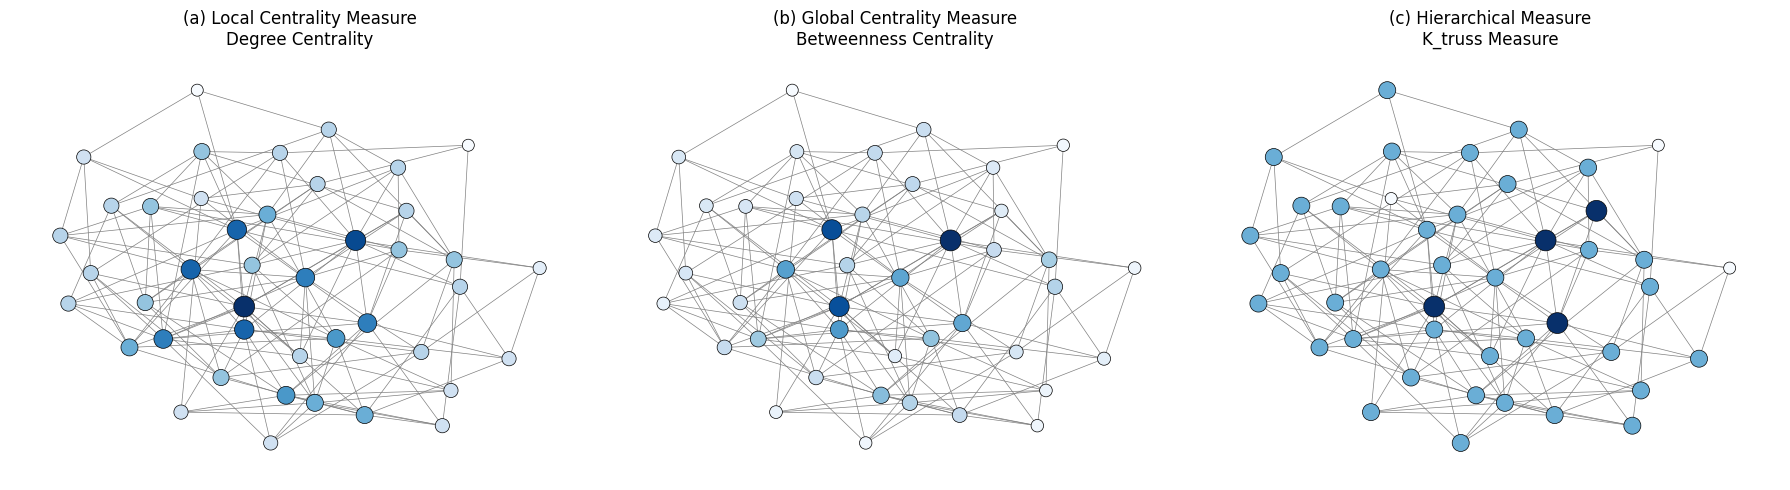

In [ ]:
# 1. Generate graph via Stochastic Block Model
# sizes = [30, 20]
# probs = [[0.8, 0.1], [0.1, 0.7]]
# G = nx.stochastic_block_model(sizes, probs, seed=42)
# G = nx.random_partition_graph([100], p_in=0.8, p_out=0.1, seed=42)
# G = nx.planted_partition_graph(l=1, k=50, p_in=0.3, p_out=0.1, seed=42)
# G = nx.random_regular_graph(d=4, n=30, seed=42)
G = nx.planted_partition_graph(l=1, k=40, p_in=0.3, p_out=0.1, seed=42)

# 2. parameters for your hubs
num_hubs   = 3     # how many high-degree nodes to add
hub_degree = 20    # how many connections each hub should have

# 3. add the hubs
next_id = max(G.nodes) + 1
for i in range(num_hubs):
    hub = next_id + i
    G.add_node(hub)
    # pick hub_degree distinct existing nodes at random
    targets = random.sample(list(G.nodes - {hub}), hub_degree)
    for t in targets:
        G.add_edge(hub, t)

# 2. Detect communities for coloring

communities, G1, part = detect_communities(G)

# communities = list(nx.community.greedy_modularity_communities(G))
community_map = {n: idx for idx, com in enumerate(communities) for n in com}

# 3. Separate and sample edges (20% intra, 5% inter)
intra_edges = [e for e in G.edges() if community_map[e[0]] == community_map[e[1]]]
inter_edges = [e for e in G.edges() if community_map[e[0]] != community_map[e[1]]]
sampled_intra = random.sample(intra_edges, int(len(intra_edges) * 0.5))
sampled_inter = random.sample(inter_edges, int(len(inter_edges) * 0.1))
sampled_edges = sampled_intra + sampled_inter

# 4. Prune to sampled edges and largest connected component
G.remove_edges_from([e for e in G.edges() if e not in sampled_edges])
largest_cc = max(nx.connected_components(G), key=len)
G = G.subgraph(largest_cc).copy()
sampled_edges = [e for e in sampled_edges if e[0] in G and e[1] in G]


graph_properties = compute_graph_properties(G)
print(f"==>> graph_properties: {graph_properties}")

density = graph_properties["density"]
transitivity = graph_properties["transitivity"]
mixing_param = graph_properties["mixing_parameter"]



communities, G1, part = detect_communities(G)

community_labels = attach_communities(G, communities)


intra_graph, inter_graph = separate_graphs_if_needed(G, communities)

CENTRALITY_SPECS = {
    "betweenness":      CentralitySpec(cal_betweenness_centrality, G),
    "pagerank":         CentralitySpec(nx.pagerank, G, False, {"alpha": 0.85}),
    "local_betweenness": CentralitySpec(cal_betweenness_centrality, intra_graph),
    "global_betweenness": CentralitySpec(cal_betweenness_centrality, inter_graph),
    "degree":           CentralitySpec(nx.degree_centrality, G),
    "local_degree":     CentralitySpec(nx.degree_centrality, intra_graph),
    "global_degree":    CentralitySpec(nx.degree_centrality, inter_graph),
    "eigenvector":      CentralitySpec(nx.eigenvector_centrality, G, True, {"max_iter": 600}),
    "local_eigenvector": CentralitySpec(nx.eigenvector_centrality, intra_graph, True, {"max_iter": 600}),
    "global_eigenvector": CentralitySpec(nx.eigenvector_centrality, inter_graph, True, {"max_iter": 600}),
    "closeness":        CentralitySpec(nx.closeness_centrality, G),
    "local_closeness":  CentralitySpec(nx.closeness_centrality, intra_graph),
    "global_closeness": CentralitySpec(nx.closeness_centrality, inter_graph),
    "local_pagerank":   CentralitySpec(nx.pagerank, intra_graph, False, {"alpha": 0.85}),
    "global_pagerank":  CentralitySpec(nx.pagerank, inter_graph, False, {"alpha": 0.85}),
    "k_core":           CentralitySpec(cal_k_core, G, True),
    "k_truss":          CentralitySpec(cal_k_truss, G),
    "Comm":             CentralitySpec(lambda g: comm_centrality(g, community_labels), G),
    "mv":               CentralitySpec(lambda g: modularity_vitality(G1, part), G),
}

# 5. Compute and normalize centralities
# def normalize(vals, low=0.5, high=2.0):
def normalize(vals, low=1, high=3.0):
    vmin, vmax = min(vals), max(vals)
    return [low + (v - vmin) / (vmax - vmin) * (high - low) for v in vals]

def cal_centrality(G, name, func):
    return func(G)
                      
metrics = {}
# metrics['Community'] = ([75] * G.number_of_nodes(), [community_map[n] for n in G.nodes()])

cn_measures = ["degree", "betweenness", "k_truss"]
# cn_measures = ["degree", "pagerank", "betweenness", "k_truss", "mv"]
for measure in cn_measures:
    spec = CENTRALITY_SPECS.get(measure)
    values = spec.cal_centrality()
    metrics[measure] = ([v * 75 for v in normalize(list(values.values()))], normalize(list(values.values())))
    
# 6. Plot in 2 rows × 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()
metrics_keys = list(metrics.keys())

# axes[0].set_title(f"(a) High Density\nDensity={density:.2f}, Edges={n_edges}", fontsize=12)
titles = [
    "(a) Local Centrality Measure\nDegree Centrality",
    "(b) Global Centrality Measure\nBetweenness Centrality",
    "(c) Hierarchical Measure\nK_truss Measure"
    ]

i = 0
for ax, mk in zip(axes, metrics_keys):
    sizes, colors = metrics[mk]
    # Choose colormap based on metric
    cmap = plt.cm.Blues if mk not in ['Uniform', 'Community'] else (plt.cm.tab10 if mk=='Community' else None)
    nx.draw(
        G,
        # pos=nx.multipartite_layout(G),
        pos=nx.kamada_kawai_layout(G),
        # pos=nx.spring_layout(G, seed=42),
        ax=ax,
        node_size=sizes,
        node_color=colors,
        cmap=cmap,
        edgecolors='black',
        linewidths=0.5,
        with_labels=False,
        edgelist=sampled_edges,
        edge_color='gray',
        width=0.5
    )
    ax.set_title(titles[i])
    i += 1

plt.tight_layout(h_pad=5.0)
plt.show()

==>> graph_properties: {'name': None, 'number_of_nodes': 90, 'number_of_edges': 552, 'max_degree': 18, 'avg_degree': 12.266666666666667, 'transitivity': 0.4097179644389945, 'density': 0.13782771535580524, 'mixing_parameter': 0.009057971014492754}


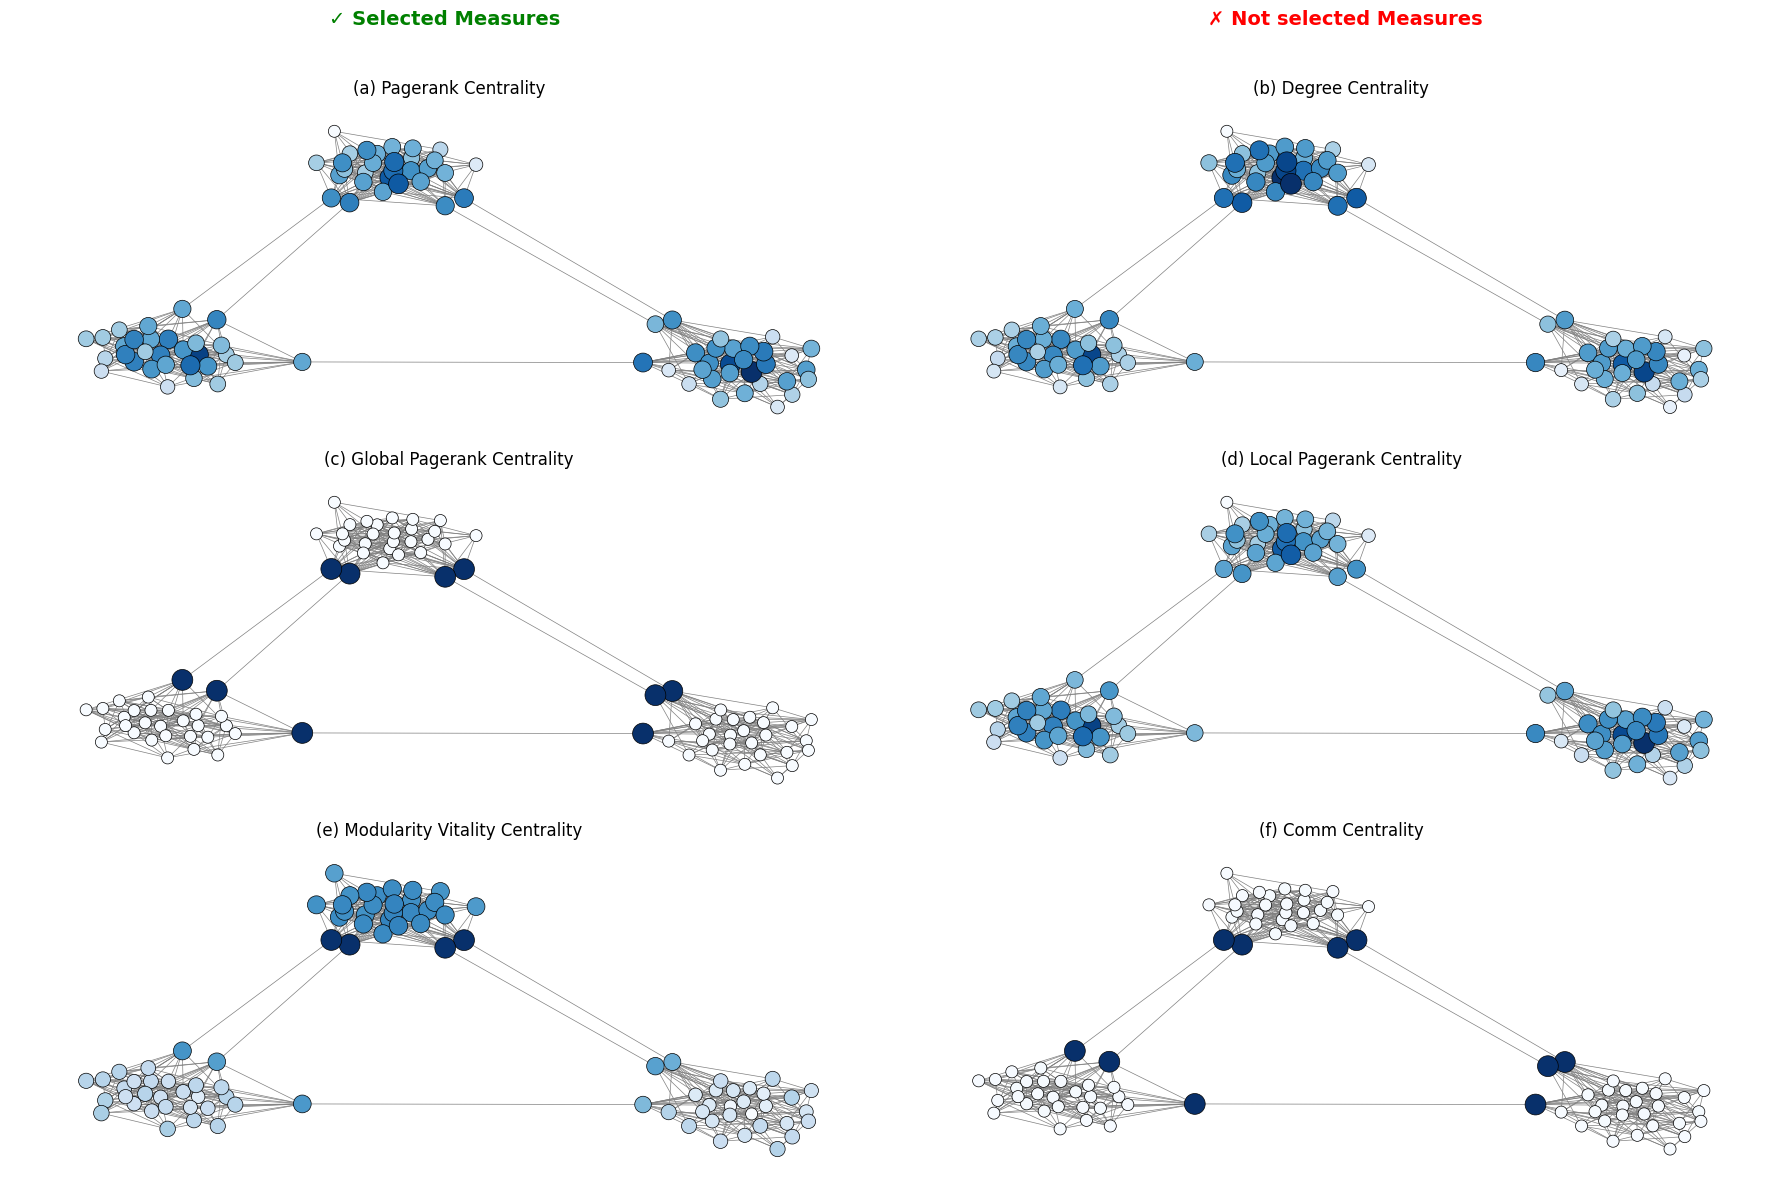

In [39]:
# 1. Generate graph via Stochastic Block Model
sizes = [30, 30, 30]
probs = [[0.8, 0.05, 0.02], [0.05, 0.7, 0.05], [0.02, 0.05, 0.6]]
G = nx.stochastic_block_model(sizes, probs, seed=42)

# 2. Detect communities for coloring

communities, G1, part = detect_communities(G)

# communities = list(nx.community.greedy_modularity_communities(G))
community_map = {n: idx for idx, com in enumerate(communities) for n in com}

# 3. Separate and sample edges (20% intra, 5% inter)
intra_edges = [e for e in G.edges() if community_map[e[0]] == community_map[e[1]]]
inter_edges = [e for e in G.edges() if community_map[e[0]] != community_map[e[1]]]
sampled_intra = random.sample(intra_edges, int(len(intra_edges) * 0.6))
sampled_inter = random.sample(inter_edges, int(len(inter_edges) * 0.05))
sampled_edges = sampled_intra + sampled_inter

# 4. Prune to sampled edges and largest connected component
G.remove_edges_from([e for e in G.edges() if e not in sampled_edges])
largest_cc = max(nx.connected_components(G), key=len)
G = G.subgraph(largest_cc).copy()
sampled_edges = [e for e in sampled_edges if e[0] in G and e[1] in G]


graph_properties = compute_graph_properties(G)
print(f"==>> graph_properties: {graph_properties}")

density = graph_properties["density"]
transitivity = graph_properties["transitivity"]
mixing_param = graph_properties["mixing_parameter"]



communities, G1, part = detect_communities(G)

community_labels = attach_communities(G, communities)


intra_graph, inter_graph = separate_graphs_if_needed(G, communities)

CENTRALITY_SPECS = {
    "betweenness":      CentralitySpec(cal_betweenness_centrality, G),
    "pagerank":         CentralitySpec(nx.pagerank, G, False, {"alpha": 0.85}),
    "local_betweenness": CentralitySpec(cal_betweenness_centrality, intra_graph),
    "global_betweenness": CentralitySpec(cal_betweenness_centrality, inter_graph),
    "degree":           CentralitySpec(nx.degree_centrality, G),
    "local_degree":     CentralitySpec(nx.degree_centrality, intra_graph),
    "global_degree":    CentralitySpec(nx.degree_centrality, inter_graph),
    "eigenvector":      CentralitySpec(nx.eigenvector_centrality, G, True, {"max_iter": 600}),
    "local_eigenvector": CentralitySpec(nx.eigenvector_centrality, intra_graph, True, {"max_iter": 600}),
    "global_eigenvector": CentralitySpec(nx.eigenvector_centrality, inter_graph, True, {"max_iter": 600}),
    "closeness":        CentralitySpec(nx.closeness_centrality, G),
    "local_closeness":  CentralitySpec(nx.closeness_centrality, intra_graph),
    "global_closeness": CentralitySpec(nx.closeness_centrality, inter_graph),
    "local_pagerank":   CentralitySpec(nx.pagerank, intra_graph, False, {"alpha": 0.85}),
    "global_pagerank":  CentralitySpec(nx.pagerank, inter_graph, False, {"alpha": 0.85}),
    "k_core":           CentralitySpec(cal_k_core, G, True),
    "k_truss":          CentralitySpec(cal_k_truss, G),
    "Comm":             CentralitySpec(lambda g: comm_centrality(g, community_labels), G),
    "mv":               CentralitySpec(lambda g: modularity_vitality(G1, part), G),
}

# 5. Compute and normalize centralities
# def normalize(vals, low=0.5, high=2.0):
def normalize(vals, low=1, high=3.0):
    vmin, vmax = min(vals), max(vals)
    return [low + (v - vmin) / (vmax - vmin) * (high - low) for v in vals]

def cal_centrality(G, name, func):
    return func(G)
                      
metrics = {}
# metrics['Community'] = ([75] * G.number_of_nodes(), [community_map[n] for n in G.nodes()])

cn_measures = ["pagerank", "degree", "global_pagerank", "local_pagerank", "mv", "Comm"]
for measure in cn_measures:
    spec = CENTRALITY_SPECS.get(measure)
    values = spec.cal_centrality()
    metrics[measure] = ([v * 75 for v in normalize(list(values.values()))], normalize(list(values.values())))
    
# 6. Plot in 2 rows × 3 columns
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()
metrics_keys = list(metrics.keys())
titles = ["(a) Pagerank Centrality", "(b) Degree Centrality", "(c) Global Pagerank Centrality", "(d) Local Pagerank Centrality", "(e) Modularity Vitality Centrality", "(f) Comm Centrality"]

i = 0
for ax, mk in zip(axes, metrics_keys):
    sizes, colors = metrics[mk]
    # Choose colormap based on metric
    cmap = plt.cm.Blues if mk not in ['Uniform', 'Community'] else (plt.cm.tab10 if mk=='Community' else None)
    nx.draw(
        G, pos=nx.spring_layout(G, seed=42), ax=ax,
        node_size=sizes,
        node_color=colors,
        cmap=cmap,
        edgecolors='black',
        linewidths=0.5,
        with_labels=False,
        edgelist=sampled_edges,
        edge_color='gray',
        width=0.5
    )
    ax.set_title(titles[i])
    i += 1
    
fig.text(
    0.25, 0.97,
    "✓ Selected Measures",
    ha="center", va="bottom",
    fontsize=14, fontweight="bold",
    color="green"
)
fig.text(
    0.75, 0.97,
    "✗ Not selected Measures",
    ha="center", va="bottom",
    fontsize=14, fontweight="bold",
    color="red"
)

# Adjust layout to make room
plt.tight_layout(rect=[0, 0, 1, 0.94])
# plt.tight_layout(h_pad=5.0)
plt.show()


In [ ]:
# # 1. Generate graph via Stochastic Block Model
# # sizes = [30, 30, 30]
# # probs = [[0.8, 0.05, 0.02], [0.05, 0.7, 0.05], [0.02, 0.05, 0.6]]
# # G = nx.stochastic_block_model(sizes, probs, seed=42)

# # # 2. Detect communities for coloring

# # communities, G1, part = detect_communities(G)

# # # communities = list(nx.community.greedy_modularity_communities(G))
# # community_map = {n: idx for idx, com in enumerate(communities) for n in com}

# # # 3. Separate and sample edges (20% intra, 5% inter)
# # intra_edges = [e for e in G.edges() if community_map[e[0]] == community_map[e[1]]]
# # inter_edges = [e for e in G.edges() if community_map[e[0]] != community_map[e[1]]]
# # sampled_intra = random.sample(intra_edges, int(len(intra_edges) * 0.5))
# # sampled_inter = random.sample(inter_edges, int(len(inter_edges) * 0.1))
# # sampled_edges = sampled_intra + sampled_inter

# # 4. Prune to sampled edges and largest connected component
# G.remove_edges_from([e for e in G.edges() if e not in sampled_edges])
# largest_cc = max(nx.connected_components(G), key=len)
# G = G.subgraph(largest_cc).copy()
# sampled_edges = [e for e in sampled_edges if e[0] in G and e[1] in G]


# graph_properties = compute_graph_properties(G)
# print(f"==>> graph_properties: {graph_properties}")

# density = graph_properties["density"]
# transitivity = graph_properties["transitivity"]
# mixing_param = graph_properties["mixing_parameter"]
# pos = nx.spring_layout(G, seed=42)


# communities, G1, part = detect_communities(G)

# community_labels = attach_communities(G, communities)


# intra_graph, inter_graph = separate_graphs_if_needed(G, communities)

# CENTRALITY_SPECS = {
#     "betweenness":      CentralitySpec(cal_betweenness_centrality, G),
#     "pagerank":         CentralitySpec(nx.pagerank, G, False, {"alpha": 0.85}),
#     "local_betweenness": CentralitySpec(cal_betweenness_centrality, intra_graph),
#     "global_betweenness": CentralitySpec(cal_betweenness_centrality, inter_graph),
#     "degree":           CentralitySpec(nx.degree_centrality, G),
#     "local_degree":     CentralitySpec(nx.degree_centrality, intra_graph),
#     "global_degree":    CentralitySpec(nx.degree_centrality, inter_graph),
#     "eigenvector":      CentralitySpec(nx.eigenvector_centrality, G, True, {"max_iter": 600}),
#     "local_eigenvector": CentralitySpec(nx.eigenvector_centrality, intra_graph, True, {"max_iter": 600}),
#     "global_eigenvector": CentralitySpec(nx.eigenvector_centrality, inter_graph, True, {"max_iter": 600}),
#     "closeness":        CentralitySpec(nx.closeness_centrality, G),
#     "local_closeness":  CentralitySpec(nx.closeness_centrality, intra_graph),
#     "global_closeness": CentralitySpec(nx.closeness_centrality, inter_graph),
#     "local_pagerank":   CentralitySpec(nx.pagerank, intra_graph, False, {"alpha": 0.85}),
#     "global_pagerank":  CentralitySpec(nx.pagerank, inter_graph, False, {"alpha": 0.85}),
#     "k_core":           CentralitySpec(cal_k_core, G, True),
#     "k_truss":          CentralitySpec(cal_k_truss, G),
#     "Comm":             CentralitySpec(lambda g: comm_centrality(g, community_labels), G),
#     "mv":               CentralitySpec(lambda g: modularity_vitality(G1, part), G),
# }

# # 5. Compute and normalize centralities
# # def normalize(vals, low=0.5, high=2.0):
# def normalize(vals, low=1, high=3.0):
#     vmin, vmax = min(vals), max(vals)
#     return [low + (v - vmin) / (vmax - vmin) * (high - low) for v in vals]

# def cal_centrality(G, name, func):
#     return func(G)
                      
# metrics = {}
# metrics['Community'] = ([75] * G.number_of_nodes(), [community_map[n] for n in G.nodes()])

# all_cn_measures = [
#     # 'betweenness', 'local_betweenness', 'global_betweenness',
#     'degree', 'local_degree', 'global_degree',
#     # 'eigenvector', 'local_eigenvector', 'global_eigenvector',
#     'closeness', 'local_closeness', 'global_closeness',
#     'pagerank', 'local_pagerank', 'global_pagerank',
#     'k_core', 'k_truss',
#     'Comm', 'mv'
# ]

# # precompute metrics
# metrics = {}
# for measure in all_cn_measures:
#     spec = CENTRALITY_SPECS[measure]
#     values = spec.cal_centrality()
#     sizes, colors = [v * 75 for v in normalize(list(values.values()))], normalize(list(values.values()))
#     metrics[measure] = (sizes, colors)

# # now plot each separately
# for mk in all_cn_measures:
#     sizes, colors = metrics[mk]
#     fig, ax = plt.subplots(figsize=(3, 3))
#     nx.draw(
#         G,
#         pos=pos,
#         ax=ax,
#         node_size=sizes,
#         node_color=colors,
#         cmap=plt.cm.Blues,
#         edgecolors='black',
#         linewidths=0.5,
#         with_labels=False,
#         edgelist=sampled_edges,
#         edge_color='gray',
#         width=0.5
#     )
#     ax.set_title(f"{mk}", fontsize=14)
#     plt.tight_layout()
#     plt.show()

==>> graph_properties: {'name': None, 'number_of_nodes': 75, 'number_of_edges': 326, 'max_degree': 16, 'avg_degree': 8.693333333333333, 'transitivity': 0.3234763793725207, 'density': 0.11747747747747747, 'mixing_parameter': 0.018404907975460124}


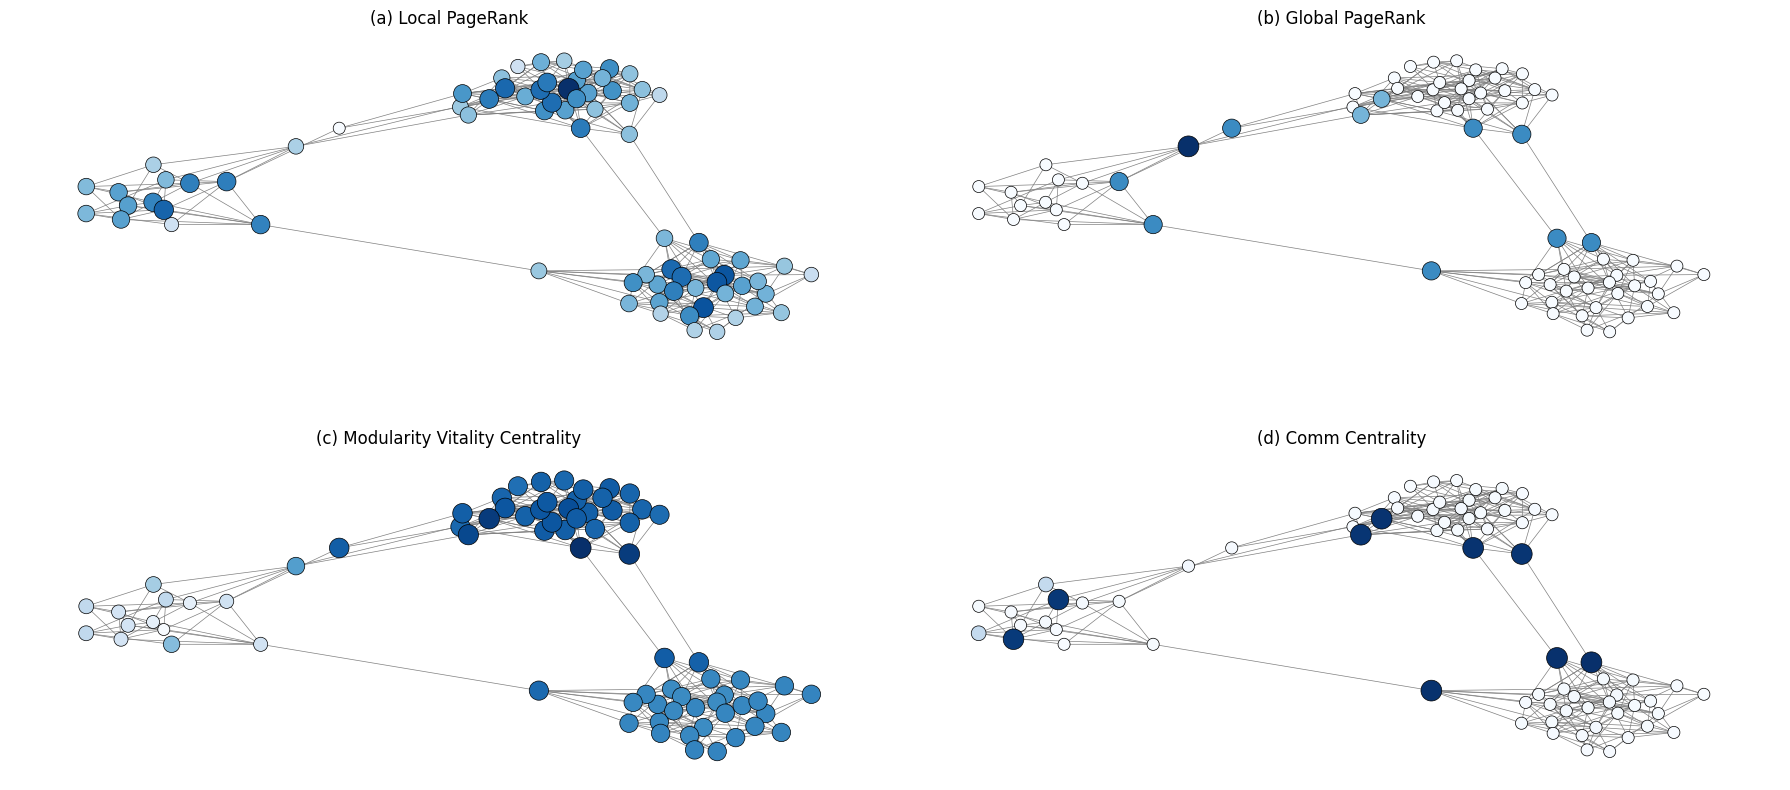

In [13]:
# 1. Generate graph via Stochastic Block Model
sizes = [15, 30, 30]
probs = [[0.8, 0.05, 0.02], [0.05, 0.7, 0.05], [0.02, 0.05, 0.6]]
G = nx.stochastic_block_model(sizes, probs, seed=42)

# 2. Detect communities for coloring

communities, G1, part = detect_communities(G)

# communities = list(nx.community.greedy_modularity_communities(G))
community_map = {n: idx for idx, com in enumerate(communities) for n in com}

# 3. Separate and sample edges (20% intra, 5% inter)
intra_edges = [e for e in G.edges() if community_map[e[0]] == community_map[e[1]]]
inter_edges = [e for e in G.edges() if community_map[e[0]] != community_map[e[1]]]
sampled_intra = random.sample(intra_edges, int(len(intra_edges) * 0.5))
sampled_inter = random.sample(inter_edges, int(len(inter_edges) * 0.1))
sampled_edges = sampled_intra + sampled_inter

# 4. Prune to sampled edges and largest connected component
G.remove_edges_from([e for e in G.edges() if e not in sampled_edges])
largest_cc = max(nx.connected_components(G), key=len)
G = G.subgraph(largest_cc).copy()
sampled_edges = [e for e in sampled_edges if e[0] in G and e[1] in G]


graph_properties = compute_graph_properties(G)
print(f"==>> graph_properties: {graph_properties}")

density = graph_properties["density"]
transitivity = graph_properties["transitivity"]
mixing_param = graph_properties["mixing_parameter"]



communities, G1, part = detect_communities(G)

community_labels = attach_communities(G, communities)


intra_graph, inter_graph = separate_graphs_if_needed(G, communities)

CENTRALITY_SPECS = {
    "betweenness":      CentralitySpec(cal_betweenness_centrality, G),
    "pagerank":         CentralitySpec(nx.pagerank, G, False, {"alpha": 0.85}),
    "local_betweenness": CentralitySpec(cal_betweenness_centrality, intra_graph),
    "global_betweenness": CentralitySpec(cal_betweenness_centrality, inter_graph),
    "degree":           CentralitySpec(nx.degree_centrality, G),
    "local_degree":     CentralitySpec(nx.degree_centrality, intra_graph),
    "global_degree":    CentralitySpec(nx.degree_centrality, inter_graph),
    "eigenvector":      CentralitySpec(nx.eigenvector_centrality, G, True, {"max_iter": 600}),
    "local_eigenvector": CentralitySpec(nx.eigenvector_centrality, intra_graph, True, {"max_iter": 600}),
    "global_eigenvector": CentralitySpec(nx.eigenvector_centrality, inter_graph, True, {"max_iter": 600}),
    "closeness":        CentralitySpec(nx.closeness_centrality, G),
    "local_closeness":  CentralitySpec(nx.closeness_centrality, intra_graph),
    "global_closeness": CentralitySpec(nx.closeness_centrality, inter_graph),
    "local_pagerank":   CentralitySpec(nx.pagerank, intra_graph, False, {"alpha": 0.85}),
    "global_pagerank":  CentralitySpec(nx.pagerank, inter_graph, False, {"alpha": 0.85}),
    "k_core":           CentralitySpec(cal_k_core, G, True),
    "k_truss":          CentralitySpec(cal_k_truss, G),
    "Comm":             CentralitySpec(lambda g: comm_centrality(g, community_labels), G),
    "mv":               CentralitySpec(lambda g: modularity_vitality(G1, part), G),
}

# 5. Compute and normalize centralities
# def normalize(vals, low=0.5, high=2.0):
def normalize(vals, low=1, high=3.0):
    vmin, vmax = min(vals), max(vals)
    return [low + (v - vmin) / (vmax - vmin) * (high - low) for v in vals]

def cal_centrality(G, name, func):
    return func(G)
                      
metrics = {}
# metrics['Community'] = ([75] * G.number_of_nodes(), [community_map[n] for n in G.nodes()])

cn_measures = ["local_pagerank", "global_pagerank", "mv", "Comm"]
for measure in cn_measures:
    spec = CENTRALITY_SPECS.get(measure)
    values = spec.cal_centrality()
    metrics[measure] = ([v * 75 for v in normalize(list(values.values()))], normalize(list(values.values())))
    
# 6. Plot in 2 rows × 3 columns
fig, axes = plt.subplots(2, 2, figsize=(18, 8))
axes = axes.flatten()
metrics_keys = list(metrics.keys())
titles = ["(a) Local PageRank", "(b) Global PageRank", "(c) Modularity Vitality Centrality", "(d) Comm Centrality"]

i = 0
for ax, mk in zip(axes, metrics_keys):
    sizes, colors = metrics[mk]
    # Choose colormap based on metric
    cmap = plt.cm.Blues if mk not in ['Uniform', 'Community'] else (plt.cm.tab10 if mk=='Community' else None)
    nx.draw(
        G, pos=nx.spring_layout(G, seed=42), ax=ax,
        node_size=sizes,
        node_color=colors,
        cmap=cmap,
        edgecolors='black',
        linewidths=0.5,
        with_labels=False,
        edgelist=sampled_edges,
        edge_color='gray',
        width=0.5
    )
    ax.set_title(titles[i])
    i += 1

plt.tight_layout(h_pad=5.0)
plt.show()


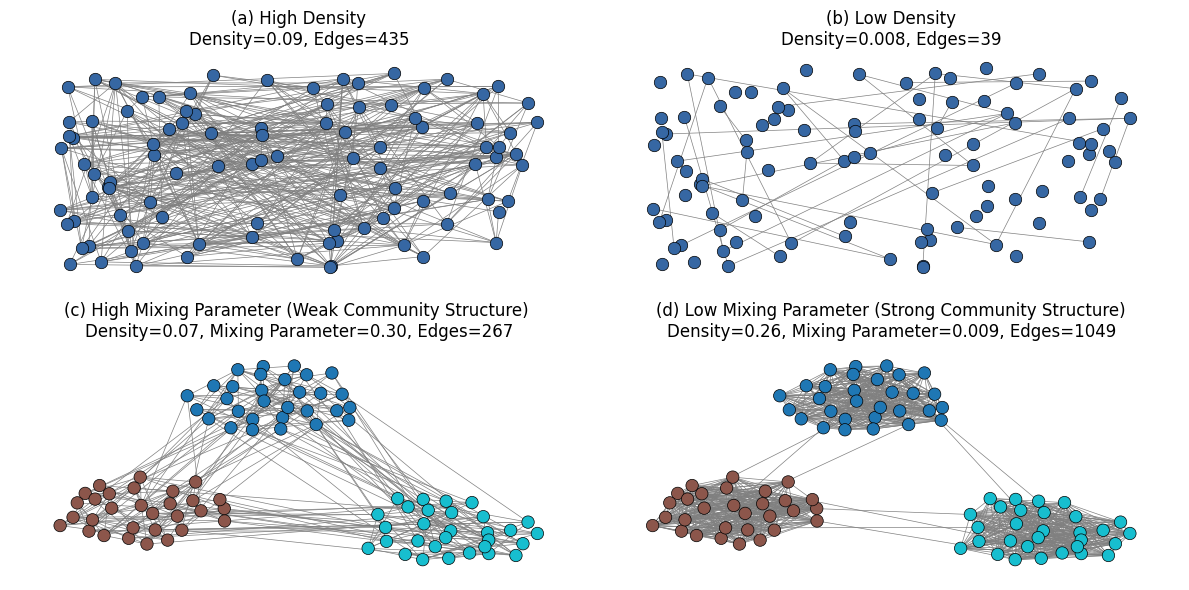

In [21]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# Block sizes
sizes_1 = [100]
sizes = [30, 30, 30]

# 1. Define the four probability matrices
P_high_density = [
    [0.093]
]
P_low_density = [
    [0.008]
]
# For high‐mixing, we'll sample edges later to keep graph sparse
P_high_mixing = [
    [0.2, 0.15, 0.15],
    [0.15, 0.2, 0.15],
    [0.15, 0.15, 0.2]
]
P_low_mixing = [
    [0.8, 0.02, 0.02],
    [0.02, 0.8, 0.02],
    [0.02, 0.02, 0.8]
]

# 2. Precompute a fixed layout (using the high‐density graph)
G_ref_den = nx.stochastic_block_model(sizes_1, P_high_density, seed=42)
pos_den  = nx.random_layout(G_ref_den, seed=1)
G_ref = nx.stochastic_block_model(sizes, P_low_mixing, seed=42)
pos   = nx.spring_layout(G_ref, seed=42)

# 3. Create a 2×2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

### Panel 1: High Density (uniform color, show # edges) ###
G_hd     = nx.stochastic_block_model(sizes_1, P_high_density, seed=42)
density  = nx.density(G_hd)
n_edges  = G_hd.number_of_edges()

nx.draw(
    G_hd, pos=pos_den, ax=axes[0],
    node_size=80,
    node_color="#3667a3",
    with_labels=False,
    edgecolors='black',
    edge_color="gray",
    linewidths=0.5,
    width=0.5,
)
axes[0].set_title(f"(a) High Density\nDensity={density:.2f}, Edges={n_edges}", fontsize=12)
axes[0].axis("off")


### Panel 2: Low Density (uniform color, show # edges) ###
G_ld     = nx.stochastic_block_model(sizes_1, P_low_density, seed=42)
density  = nx.density(G_ld)
n_edges  = G_ld.number_of_edges()

nx.draw(
    G_ld, pos=pos_den, ax=axes[1],
    node_size=80,
    node_color="#3667a3",
    with_labels=False,
    edgecolors='black',
    edge_color="gray",
    linewidths=0.5,
    width=0.5,
)
axes[1].set_title(f"(b) Low Density\nDensity={density:.3f}, Edges={n_edges}", fontsize=12)
axes[1].axis("off")


### Panel 3: Sparse High Mixing (sampled) ###
# Generate full SBM and get planted communities
G0 = nx.stochastic_block_model(sizes, P_high_mixing, seed=42)
planted = nx.get_node_attributes(G0, "block")

# Separate edges
intra = [(u, v) for u, v in G0.edges() if planted[u] == planted[v]]
inter = [(u, v) for u, v in G0.edges() if planted[u] != planted[v]]

# Sample to keep graph sparse but inter/intra ratio high
frac_intra = 0.8   # keep 10% of intra‐block edges
frac_inter = 0.2   # keep 75% of inter‐block edges
sampled = (
    random.sample(intra, int(len(intra) * frac_intra)) +
    random.sample(inter, int(len(inter) * frac_inter))
)

# Build the pruned graph
G_hm = nx.Graph()
G_hm.add_nodes_from(G0.nodes())
G_hm.add_edges_from(sampled)

# Compute density & mixing
density = nx.density(G_hm)
inter_count = sum(1 for u, v in G_hm.edges() if planted[u] != planted[v])
mixing = inter_count / G_hm.number_of_edges()

# Draw colored by planted blocks
colors = [planted[n] for n in G_hm.nodes()]
nx.draw(
    G_hm, pos=pos, ax=axes[2],
    node_size=80,
    node_color=colors,
    cmap=plt.cm.tab10,
    with_labels=False,
    edgecolors='black',
    edge_color="gray",
    linewidths=0.5,
    width=0.5,
)
axes[2].set_title(
    f"(c) High Mixing Parameter (Weak Community Structure) \n"
    f"Density={density:.2f}, Mixing Parameter={mixing:.2f}, Edges={G_hm.number_of_edges()}",
    fontsize=12
)
axes[2].axis("off")


### Panel 4: Low Mixing (planted blocks) ###
G1 = nx.stochastic_block_model(sizes, P_low_mixing, seed=42)
planted = nx.get_node_attributes(G1, "block")

# Separate edges
intra = [(u, v) for u, v in G1.edges() if planted[u] == planted[v]]
inter = [(u, v) for u, v in G1.edges() if planted[u] != planted[v]]

# Sample to keep graph sparse but inter/intra ratio high
frac_intra = 1   # keep 10% of intra‐block edges
frac_inter = 0.13   # keep 75% of inter‐block edges
sampled = (
    random.sample(intra, int(len(intra) * frac_intra)) +
    random.sample(inter, int(len(inter) * frac_inter))
)

# Build the pruned graph
G_lm = nx.Graph()
G_lm.add_nodes_from(G1.nodes())
G_lm.add_edges_from(sampled)

planted = nx.get_node_attributes(G1, "block")
density = nx.density(G_lm)
inter_count = sum(1 for u, v in G_lm.edges() if planted[u] != planted[v])
mixing = inter_count / G_lm.number_of_edges()
colors = [planted[n] for n in G_lm.nodes()]

nx.draw(
    G_lm, pos=pos, ax=axes[3],
    node_size=80,
    node_color=colors,
    cmap=plt.cm.tab10,
    with_labels=False,
    edgecolors='black',
    edge_color="gray",
    linewidths=0.5,
    width=0.5,
)
axes[3].set_title(f"(d) Low Mixing Parameter (Strong Community Structure)\nDensity={density:.2f}, Mixing Parameter={mixing:.3f}, Edges={G_lm.number_of_edges()}", fontsize=12)
axes[3].axis("off")


plt.tight_layout()
plt.show()

